In [1]:
import pandas as pd

print(pd.__version__)

2.3.3


In [2]:
data = [10, 20, 30, 40]

s = pd.Series(data)

print(s)

0    10
1    20
2    30
3    40
dtype: int64


In [3]:
s = pd.Series([10,20,30], index=["a","b","c"])
print(s)

a    10
b    20
c    30
dtype: int64


In [4]:
data = {
    "Name": ["A", "B", "C"],
    "Age": [20, 25, 30],
    "Marks": [85, 90, 95]
}

df = pd.DataFrame(data)

print(df)

  Name  Age  Marks
0    A   20     85
1    B   25     90
2    C   30     95


In [5]:
print(df.head())   # first rows
print(df.tail())   # last rows
print(df.shape)
print(df.columns)
print(df.info())

  Name  Age  Marks
0    A   20     85
1    B   25     90
2    C   30     95
  Name  Age  Marks
0    A   20     85
1    B   25     90
2    C   30     95
(3, 3)
Index(['Name', 'Age', 'Marks'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      int64 
 2   Marks   3 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 204.0+ bytes
None


In [6]:
print(df["Name"])

print(df[["Name","Marks"]])

0    A
1    B
2    C
Name: Name, dtype: object
  Name  Marks
0    A     85
1    B     90
2    C     95


In [7]:
print(df.loc[0])       # by label
print(df.iloc[1])      # by index

print(df.iloc[0:2])

Name      A
Age      20
Marks    85
Name: 0, dtype: object
Name      B
Age      25
Marks    90
Name: 1, dtype: object
  Name  Age  Marks
0    A   20     85
1    B   25     90


In [8]:
df["Grade"] = ["B", "A", "A"]

print(df)

  Name  Age  Marks Grade
0    A   20     85     B
1    B   25     90     A
2    C   30     95     A


In [9]:
df = df.drop("Grade", axis=1)

print(df)

  Name  Age  Marks
0    A   20     85
1    B   25     90
2    C   30     95


In [10]:
filtered = df[df["Marks"] > 85]

print(filtered)

  Name  Age  Marks
1    B   25     90
2    C   30     95


In [11]:
filtered = df[(df["Marks"] > 80) & (df["Age"] > 22)]

print(filtered)

  Name  Age  Marks
1    B   25     90
2    C   30     95


In [12]:
print(df.sort_values(by="Marks"))

print(df.sort_values(by="Marks", ascending=False))

  Name  Age  Marks
0    A   20     85
1    B   25     90
2    C   30     95
  Name  Age  Marks
2    C   30     95
1    B   25     90
0    A   20     85


In [13]:
print(df["Marks"].mean())
print(df["Marks"].max())
print(df["Marks"].min())
print(df["Marks"].sum())

90.0
95
85
270


In [14]:
print(df.describe())

        Age  Marks
count   3.0    3.0
mean   25.0   90.0
std     5.0    5.0
min    20.0   85.0
25%    22.5   87.5
50%    25.0   90.0
75%    27.5   92.5
max    30.0   95.0


In [15]:
def grade(marks):
    return "A" if marks >= 90 else "B"

df["Grade"] = df["Marks"].apply(grade)

print(df)

  Name  Age  Marks Grade
0    A   20     85     B
1    B   25     90     A
2    C   30     95     A


In [16]:
data = {
    "Department": ["IT","IT","HR","HR"],
    "Salary": [50000,60000,40000,45000]
}

df = pd.DataFrame(data)

grouped = df.groupby("Department")["Salary"].mean()

print(grouped)

Department
HR    42500.0
IT    55000.0
Name: Salary, dtype: float64


In [17]:
data = {
    "Name": ["A","B","C"],
    "Marks": [90, None, 80]
}

df = pd.DataFrame(data)

print(df.isnull())

df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

print(df)

    Name  Marks
0  False  False
1  False   True
2  False  False
  Name  Marks
0    A   90.0
1    B   85.0
2    C   80.0


In [18]:
df = df.rename(columns={"Marks":"Score"})

print(df)

  Name  Score
0    A   90.0
1    B   85.0
2    C   80.0


In [19]:
df["Score"] = df["Score"].astype(int)

print(df.dtypes)

Name     object
Score     int64
dtype: object


In [20]:
df = pd.read_csv("ipl-matches.csv")

print(df.head())

        ID       City        Date Season  MatchNumber  \
0  1312200  Ahmedabad  2022-05-29   2022        Final   
1  1312199  Ahmedabad  2022-05-27   2022  Qualifier 2   
2  1312198    Kolkata  2022-05-25   2022   Eliminator   
3  1312197    Kolkata  2022-05-24   2022  Qualifier 1   
4  1304116     Mumbai  2022-05-22   2022           70   

                         Team1                 Team2  \
0             Rajasthan Royals        Gujarat Titans   
1  Royal Challengers Bangalore      Rajasthan Royals   
2  Royal Challengers Bangalore  Lucknow Super Giants   
3             Rajasthan Royals        Gujarat Titans   
4          Sunrisers Hyderabad          Punjab Kings   

                              Venue            TossWinner TossDecision  \
0  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals          bat   
1  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals        field   
2             Eden Gardens, Kolkata  Lucknow Super Giants        field   
3             Eden Garde

In [21]:
df.to_csv("data.csv", index=False)

In [22]:
df1 = pd.DataFrame({
    "ID":[1,2],
    "Name":["A","B"]
})

df2 = pd.DataFrame({
    "ID":[1,2],
    "Marks":[90,80]
})

merged = pd.merge(df1, df2, on="ID")

print(merged)

   ID Name  Marks
0   1    A     90
1   2    B     80


In [23]:
df1 = pd.DataFrame({"A":[1,2]})
df2 = pd.DataFrame({"A":[3,4]})

combined = pd.concat([df1,df2])

print(combined)

   A
0  1
1  2
0  3
1  4


In [24]:
df = pd.DataFrame({
    "A":[1,1,2,3]
})

print(df.drop_duplicates())

   A
0  1
2  2
3  3


In [25]:
df = pd.DataFrame({
    "City":["A","B","A","C","B","A"]
})

print(df["City"].value_counts())

City
A    3
B    2
C    1
Name: count, dtype: int64


In [26]:
data = {
    "Name":["A","A","B","B"],
    "Subject":["Math","Sci","Math","Sci"],
    "Marks":[90,80,70,60]
}

df = pd.DataFrame(data)

pivot = df.pivot(index="Name", columns="Subject", values="Marks")

print(pivot)

Subject  Math  Sci
Name              
A          90   80
B          70   60


In [27]:
df = df.set_index("Name")

print(df)

df = df.reset_index()

print(df)

     Subject  Marks
Name               
A       Math     90
A        Sci     80
B       Math     70
B        Sci     60
  Name Subject  Marks
0    A    Math     90
1    A     Sci     80
2    B    Math     70
3    B     Sci     60


In [28]:
df = pd.DataFrame({
    "Name":["alice","bob","charlie"]
})

df["Name"] = df["Name"].str.upper()

print(df)

      Name
0    ALICE
1      BOB
2  CHARLIE


In [29]:
df = pd.DataFrame({
    "Date":["2025-01-01","2025-02-01"]
})

df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Date    datetime64[ns]
dtype: object


In [30]:
data = {
    "Name":["A","B","C","D"],
    "Marks":[90,75,85,60]
}

df = pd.DataFrame(data)

print("Average:",df["Marks"].mean())

print("Topper:",df.loc[df["Marks"].idxmax()])

print("Fail Students:\n",df[df["Marks"] < 70])

Average: 77.5
Topper: Name      A
Marks    90
Name: 0, dtype: object
Fail Students:
   Name  Marks
3    D     60


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    4 non-null      object
 1   Marks   4 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes


In [32]:
df.isnull().sum()

Name     0
Marks    0
dtype: int64

In [54]:
import pandas as pd
import numpy as np

data = {
    "Name": ["A", "B", "C", "D"],
    "Age": [20, np.nan, 25, 30],
    "Marks": [90, 85, np.nan, 70]
}

df = pd.DataFrame(data)

print(df)

  Name   Age  Marks
0    A  20.0   90.0
1    B   NaN   85.0
2    C  25.0    NaN
3    D  30.0   70.0


In [55]:
print(df.isna())

    Name    Age  Marks
0  False  False  False
1  False   True  False
2  False  False   True
3  False  False  False


In [56]:
print(df.isna().sum())

Name     0
Age      1
Marks    1
dtype: int64


In [57]:
print(df.dropna())

  Name   Age  Marks
0    A  20.0   90.0
3    D  30.0   70.0


In [58]:
print(df.dropna(axis=1))

  Name
0    A
1    B
2    C
3    D


In [59]:
print(df.dropna(how="all"))

  Name   Age  Marks
0    A  20.0   90.0
1    B   NaN   85.0
2    C  25.0    NaN
3    D  30.0   70.0


In [60]:
print(df.dropna(subset=["Marks"]))

  Name   Age  Marks
0    A  20.0   90.0
1    B   NaN   85.0
3    D  30.0   70.0


In [61]:
df_filled = df.fillna(0)
print(df_filled)

  Name   Age  Marks
0    A  20.0   90.0
1    B   0.0   85.0
2    C  25.0    0.0
3    D  30.0   70.0


In [62]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

print(df)

  Name   Age      Marks
0    A  20.0  90.000000
1    B  25.0  85.000000
2    C  25.0  81.666667
3    D  30.0  70.000000


In [63]:
df["Age"] = df["Age"].fillna(df["Age"].median())
print(df)

  Name   Age      Marks
0    A  20.0  90.000000
1    B  25.0  85.000000
2    C  25.0  81.666667
3    D  30.0  70.000000


In [64]:
df["Name"] = df["Name"].fillna(df["Name"].mode()[0])
print(df)

  Name   Age      Marks
0    A  20.0  90.000000
1    B  25.0  85.000000
2    C  25.0  81.666667
3    D  30.0  70.000000


In [65]:
print(df.isna().sum())

Name     0
Age      0
Marks    0
dtype: int64


In [66]:
print(df)

  Name   Age      Marks
0    A  20.0  90.000000
1    B  25.0  85.000000
2    C  25.0  81.666667
3    D  30.0  70.000000


In [67]:
import pandas as pd
import numpy as np

data = {
    "Marks": [50, 55, 60, 65, 70, 75, 80, 200]  # 200 is outlier
}

df = pd.DataFrame(data)

print(df)

   Marks
0     50
1     55
2     60
3     65
4     70
5     75
6     80
7    200


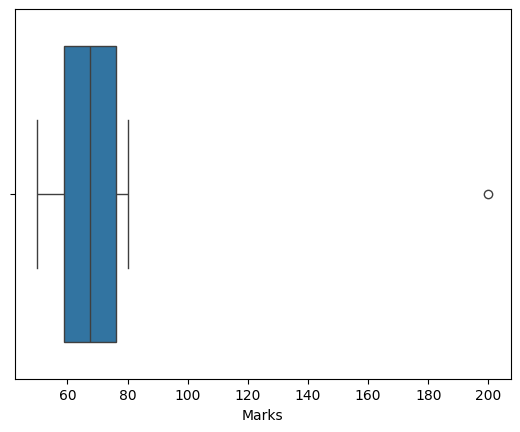

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Marks"])
plt.show()

In [69]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: 32.5
Upper: 102.5


In [70]:
outliers = df[(df["Marks"] < lower_bound) | (df["Marks"] > upper_bound)]

print("Outliers:\n", outliers)

Outliers:
    Marks
7    200


In [71]:
df_clean = df[(df["Marks"] >= lower_bound) & (df["Marks"] <= upper_bound)]

print(df_clean)

   Marks
0     50
1     55
2     60
3     65
4     70
5     75
6     80


In [72]:
df["Marks"] = np.where(
    df["Marks"] > upper_bound,
    upper_bound,
    df["Marks"]
)

df["Marks"] = np.where(
    df["Marks"] < lower_bound,
    lower_bound,
    df["Marks"]
)

print(df)

   Marks
0   50.0
1   55.0
2   60.0
3   65.0
4   70.0
5   75.0
6   80.0
7  102.5


In [73]:
df["Marks"] = df["Marks"].clip(lower_bound, upper_bound)

print(df)

   Marks
0   50.0
1   55.0
2   60.0
3   65.0
4   70.0
5   75.0
6   80.0
7  102.5


In [74]:
df["Bins"] = pd.cut(df["Marks"], bins=3)

print(df)

   Marks            Bins
0   50.0  (49.948, 67.5]
1   55.0  (49.948, 67.5]
2   60.0  (49.948, 67.5]
3   65.0  (49.948, 67.5]
4   70.0    (67.5, 85.0]
5   75.0    (67.5, 85.0]
6   80.0    (67.5, 85.0]
7  102.5   (85.0, 102.5]


In [75]:
bins = [0, 60, 80, 100]

labels = ["Low", "Medium", "High"]

df["Category"] = pd.cut(df["Marks"], bins=bins, labels=labels)

print(df)

   Marks            Bins Category
0   50.0  (49.948, 67.5]      Low
1   55.0  (49.948, 67.5]      Low
2   60.0  (49.948, 67.5]      Low
3   65.0  (49.948, 67.5]   Medium
4   70.0    (67.5, 85.0]   Medium
5   75.0    (67.5, 85.0]   Medium
6   80.0    (67.5, 85.0]   Medium
7  102.5   (85.0, 102.5]      NaN


In [76]:
df["Quantile_Bins"] = pd.qcut(df["Marks"], q=4)

print(df)

   Marks            Bins Category    Quantile_Bins
0   50.0  (49.948, 67.5]      Low  (49.999, 58.75]
1   55.0  (49.948, 67.5]      Low  (49.999, 58.75]
2   60.0  (49.948, 67.5]      Low    (58.75, 67.5]
3   65.0  (49.948, 67.5]   Medium    (58.75, 67.5]
4   70.0    (67.5, 85.0]   Medium    (67.5, 76.25]
5   75.0    (67.5, 85.0]   Medium    (67.5, 76.25]
6   80.0    (67.5, 85.0]   Medium   (76.25, 102.5]
7  102.5   (85.0, 102.5]      NaN   (76.25, 102.5]
